In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import re
from pprint import pprint
import joblib
pd.set_option('display.max_columns', None)
random_seed=123

In [2]:
import sys
sys.executable

'/Users/mac/rec_analysis/venv/bin/python'

In [3]:
%cd '/Users/mac/rec_analysis'

/Users/mac/rec_analysis


In [4]:
df = pd.read_csv('data/df.csv')
df_all= pd.read_csv('data/df_all.csv')

In [311]:
df_check[df_check['final_class']==1]['REINCIDENCIA_VIOLENTA'].value_counts(normalize=True) * 100

REINCIDENCIA_VIOLENTA
0    62.5
1    37.5
Name: proportion, dtype: float64

In [315]:
df_check[df_check['final_class']==1]['REINCIDENCIA_VIOLENTA'].value_counts(normalize=True) * 100

REINCIDENCIA_VIOLENTA
0    62.5
1    37.5
Name: proportion, dtype: float64

In [313]:
df_check[df_check['V205_R1_REVI']==3]['REINCIDENCIA_VIOLENTA'].value_counts(normalize=True) * 100

REINCIDENCIA_VIOLENTA
0    92.307692
1     7.692308
Name: proportion, dtype: float64

In [314]:
df_check[df_check['V205_R1_REVI']==1]['REINCIDENCIA_VIOLENTA'].value_counts(normalize=True) * 100

REINCIDENCIA_VIOLENTA
0    95.409836
1     4.590164
Name: proportion, dtype: float64

## Fairness in recidivism risk assesment - PART 2:

### Benchmark classification (LR + XGB)
I'm optimizing for positive class precision metric, as low precision (*~8%* for high-risk violent recidivism) has been the main objection of RisCanvi Eticas audit.

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
X = df[df.columns[:-2]].copy()
y = df['REINCIDENCIA_VIOLENTA'].copy()

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_seed, stratify=y)

print(
    ' Proportion of y=1 in train set: ', y_train.sum(), '/', len(y_train),
    '\n Proportion of y=1 in test set: ', y_test.sum(), '/', len(y_test))

 Proportion of y=1 in train set:  82 / 1617 
 Proportion of y=1 in test set:  20 / 405


**Weighting classes (imbalance)**:

In [7]:
from sklearn.utils.class_weight import compute_class_weight

In [8]:
classes = np.unique(y)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y)
sample_weights = np.zeros(len(y_train)) 
weight_dict = dict(zip(classes, weights))

for clas, weight in weight_dict.items():
    sample_weights[y_train == clas] = weight 

pos_weight = weight_dict[1]/weight_dict[0]

**Logistic regression - main assesment**:<br>
The LR model is going to be a baseline for a positive (high-risk) class assesment, because of its high interpretability. However, positive class precision enhancement (negative veto system) is going to be implemented further via XGBoost model.

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import f1_score, classification_report
from scipy.stats import loguniform

In [10]:
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        solver='lbfgs', # l2 regularization
        class_weight={0: 1, 1: pos_weight},
        random_state=random_seed,
        max_iter=1000  
    ))
])

param_grid_lr = {
    'classifier__C': loguniform(1e-3, 10) 
}

grid_search_lr = RandomizedSearchCV(
    estimator=pipeline_lr,
    param_distributions=param_grid_lr,
    n_iter=100,
    scoring='f1',
    cv=10,
    verbose=1,
    random_state=random_seed,
    n_jobs=-1
)

grid_search_lr.fit(x_train, y_train)
best_pipeline_lr = grid_search_lr.best_estimator_
print("Best parameters (LR):", grid_search_lr.best_params_)

y_pred_proba_lr = best_pipeline_lr.predict_proba(x_test)[:, 1]

best_f1_lr = 0
best_threshold_lr = 0
thresholds = np.arange(0.01, 1.00, 0.01)

for thresh in thresholds:
    y_pred_thresh = (y_pred_proba_lr >= thresh).astype(int)
    f1 = f1_score(y_test, y_pred_thresh)
    if f1 > best_f1_lr:
        best_f1_lr = f1
        best_threshold_lr = thresh

print(f"\nBest Threshold (LR): {best_threshold_lr:.2f}")
print(f"Best F1-Score (LR): {best_f1_lr:.4f}")

y_pred_final_lr = (y_pred_proba_lr >= best_threshold_lr).astype(int)
print("\nClassification report for best model & threshold (Logistic Regression):\n")
print(classification_report(y_test, y_pred_final_lr))

Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Best parameters (LR): {'classifier__C': np.float64(1.1225126789939393)}

Best Threshold (LR): 0.94
Best F1-Score (LR): 0.2069

Classification report for best model & threshold (Logistic Regression):

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       385
           1       0.33      0.15      0.21        20

    accuracy                           0.94       405
   macro avg       0.65      0.57      0.59       405
weighted avg       0.93      0.94      0.93       405



In [11]:
df_check = df.loc[x_test.index].copy()
df_check['class_rc'] = df_check['V205_R1_REVI'].apply(lambda x: 1 if x > 2 else 0) # converting riscanvi scores to binary classes for further confusion matrix comparison
df_check['score_lr'] = y_pred_proba_lr
df_check['class_lr'] = (df_check['score_lr'] >= best_threshold_lr).astype(int) # for further validation

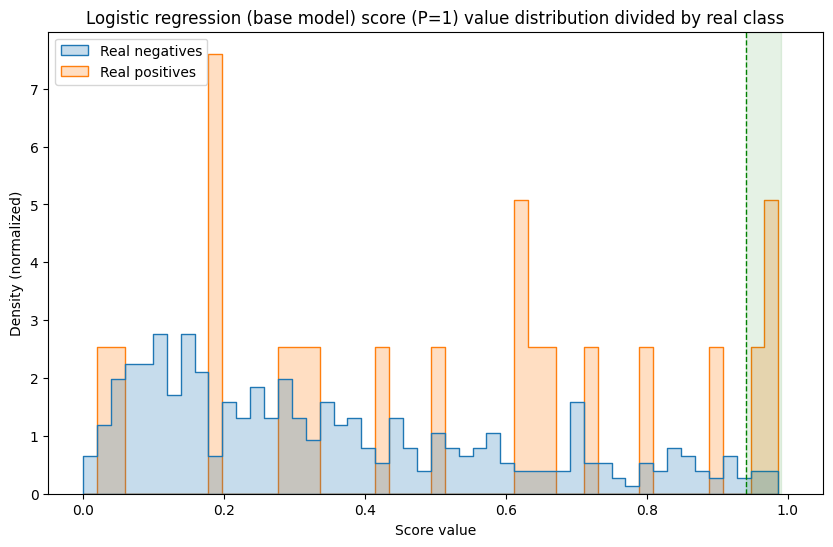

Mean score:
                       count      mean       std
REINCIDENCIA_VIOLENTA                           
0                      385.0  0.351141  0.258338
1                       20.0  0.516442  0.312403


In [67]:
plt.figure(figsize=(10, 6))

ax = sns.histplot(data=df_check, x='score_lr', hue='REINCIDENCIA_VIOLENTA', 
             bins=50, stat='density', common_norm=False, element="step")

plt.title("Logistic regression (base model) score (P=1) value distribution divided by real class")
plt.xlabel("Score value")
plt.ylabel("Density (normalized)")
plt.xlim(-0.05, 1.05)

plt.axvline(
    x=best_threshold_lr,
    color='green',
    linestyle='--',
    linewidth=1
)

plt.axvspan(best_threshold_lr, thresholds.max(), color='green', alpha=0.1)

legend = ax.legend_

label_map = {
    '0': 'Real negatives',
    '1': 'Real positives'
}

new_labels = [label_map.get(t.get_text(), t.get_text()) for t in legend.texts]

ax.legend(legend.legend_handles, new_labels)
plt.show()


print("Mean score:")
print(df_check.groupby('REINCIDENCIA_VIOLENTA')['score_lr'].describe()[['count', 'mean', 'std']])

**LR to RisCanvi comparison:**

In [13]:
print('Model score to RisCanvi score correlation:', df_check['score_lr'].corr(df_check['V205_R1_REVI'], method='pearson').round(2))
print('Model score to real recidivism correlation:', df_check['score_lr'].corr(df_check['REINCIDENCIA_VIOLENTA'], method='pearson').round(2))

Model score to RisCanvi score correlation: 0.29
Model score to real recidivism correlation: 0.14


In [14]:
print('Mean model score among RisCanvi high-score inmates:', df_check[df_check['class_rc']==1]['score_lr'].mean().round(2))
print('Mean model score among RisCanvi low/medium-score inmates:', df_check[df_check['class_rc']==0]['score_lr'].mean().round(2))

Mean model score among RisCanvi high-score inmates: 0.57
Mean model score among RisCanvi low/medium-score inmates: 0.34


In [15]:
print('RisCanvi to LR classification report:\n')
print(classification_report(df_check['class_rc'], df_check['class_lr']))

RisCanvi to LR classification report:

              precision    recall  f1-score   support

           0       0.91      0.99      0.95       366
           1       0.56      0.13      0.21        39

    accuracy                           0.91       405
   macro avg       0.73      0.56      0.58       405
weighted avg       0.88      0.91      0.88       405



I aim for moderately low positive class recall of LR to RisCanvi scores.

------

**XGBoost - auxiliary (supportive) model for positive class precision augmentation**:<br>
Despite poor positive class precision, for a negative precision value the XGBoost model greatly overranks LR under a certain threshold (100% negative class precision for almost 20% of all test set inmates). We can use it to enhance positive precision of LR scoring by eliminating possible FP edge cases (above LR optimal threshold for positive precision and below XGB optimal threshold for negative precision) from LR positive class. Such cases are indeed present in the analyzed dataset under current LR classification threshold.

In [20]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import precision_score
from xgboost import XGBClassifier
import xgboost as xgb
from scipy.stats import randint, uniform

In [21]:
param_grid = {
    'max_depth': randint(2, 15),
    'n_estimators': randint(100, 1000),
    'learning_rate': uniform(0.0001, 0.5),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 5),
    'min_child_weight': randint(1, 10)
}

xgb_base = xgb.XGBClassifier(
    enable_categorical=False,
    tree_method='hist',
    scale_pos_weight=pos_weight,
    random_state=random_seed
)

grid_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=300,
    scoring='neg_log_loss', # neg_log_loss optimization for better low negative class ranking
    cv=10,
    verbose=1,
    random_state=random_seed,
    n_jobs=-1)

grid_search.fit(x_train, y_train)
best_model = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)

y_pred_proba_best = best_model.predict_proba(x_test)[:, 1]

# veto threshold optimization
target_negative_precision = 0.99 # 'negative class protection zone'
best_veto_threshold = 0
max_vetoed_inmates = 0
positives_count = y_test.sum()
best_confidence_zone_positives_count = 0
best_confidence_zone_positives_ratio = 0

thresholds = np.arange(0.01, 1.00, 0.01)

for thresh in thresholds:

    y_pred_thresh = (y_pred_proba_best >= thresh).astype(int)
    
    neg_precision = precision_score(y_test, y_pred_thresh, pos_label=0, zero_division=0)
    
    vetoed_count = np.sum(y_pred_thresh == 0)

    confidence_zone_mask = y_pred_proba_best < thresh
    confidence_zone_positives_count = y_test[confidence_zone_mask].sum()
    confidence_zone_positives_ratio = (confidence_zone_positives_count/positives_count)*100
    
    if neg_precision >= target_negative_precision:
        if vetoed_count > max_vetoed_inmates:
            max_vetoed_inmates = vetoed_count
            best_veto_threshold = thresh
            best_neg_precision = neg_precision
            best_confidence_zone_positives_count = confidence_zone_positives_count
            best_confidence_zone_positives_ratio = confidence_zone_positives_ratio
            best_below_threshold = (max_vetoed_inmates/len(y_test))*100

print(f"\nVeto model (XGBoost) metrics:")
print(f"Optimal negative precision threshold: {best_veto_threshold:.2f}")
print(f"Negative precision: {best_neg_precision:.2f}")
print(f"All inmates with scores in confidence zone: {max_vetoed_inmates}/{len(y_test)}"
      f" ({best_below_threshold:.2f}%)")
print(f"Real positives in confidence zone: "
      f"{best_confidence_zone_positives_count}/{positives_count} "
      f" ({best_confidence_zone_positives_ratio:.2f}%)")

Fitting 10 folds for each of 300 candidates, totalling 3000 fits
Best parameters: {'colsample_bytree': np.float64(0.7140294768640183), 'gamma': np.float64(0.8210344183425633), 'learning_rate': np.float64(0.009224951047565388), 'max_depth': 9, 'min_child_weight': 4, 'n_estimators': 825, 'subsample': np.float64(0.7214646061119683)}

Veto model (XGBoost) metrics:
Optimal negative precision threshold: 0.01
Negative precision: 1.0000
All inmates with scores in confidence zone: 69/405 (17.04%)
Real positives in confidence zone: 0/20  (0.00%)


In [22]:
df_check['score_xgb'] = y_pred_proba_best
df_check['class_xgb'] = (df_check['score_xgb'] >= best_veto_threshold).astype(int)

LR & XGB scoring correlation:

In [23]:
df_check['score_lr'].corr(df_check['score_xgb'], method='pearson')

np.float64(0.5173545922269619)

Logistic regression FP vetoed by XGBoost to negative class (LR & XGB overlap):

In [24]:
df_check[(df_check['score_lr']>=best_threshold_lr) & (df_check['score_xgb']<best_veto_threshold)]

,V72_DELICTEPBVIOL,V139_EDAT_DELICTEPBASE,V76_R3C_F03_IntoxicacioDelicteBase,V77_R3C_F04_VictimesLesions,V86_DURADA_PENA_RisCanvi,V78_R3C_F07_HistoriaViolencia,V79_R3C_F08_IniciActivitatDelictiva,V80_R3C_F09_IncrementGravetatDelictes,V104_R3C_F10_ConflictesAmbInterns,V105_R3C_F11_IncomplimentsMesures,V106_R3C_F12_ExpedientsDisciplinaris,V107_R3C_F13_EvasionsFugues,V108_R3C_F14_RegressioGrau,V109_R3C_F15_TrencamentPermisos,V29_R3C_F16_DesajustInfantil,V30_R3C_F18_NivellEducatiu,V31_R3C_F19_ProblemesOcupacio,V32_R3C_F20_MancaRecursosEconomics,V33_R3C_F21_AbsenciaPlansFutur,V34_R3C_F22_AntecedentsFamilia,V35_R3C_F23_SocialitzacioProblematica,V36_R3C_F24_MancaSuportFamiliarSocial,V37_R3C_F25_PertinençaBandes,V38_R3C_F26_PertinençaGrupRisc,V39_R3C_F27_RolDelictiuDestacat,V40_R3C_F28_VictimaVIGE,V41_R3C_F29_CarreguesFamiliars,V42_R3C_F30_ConsumDrogues,V43_R3C_F31_ConsumAlcohol,V44_R3C_F32_TranstornMentalSever,V45_R3C_F33_ComportamentSexualRisc,V46_R3C_F34_RespostaLimitadaTractament,V47_R3C_F35_TranstornPersonalitat,V48_R3C_F36_PobreAfrontamentEstres,V49_R3C_F37_IntentsAutolesio,V50_R3C_F38_ActitudsProcriminals,V51_R3C_F39_BaixCI,V52_R3C_F40_Temeritat,V53_R3C_F41_Impulsivitat,V54R3C_F42_Hostilitat,V55_R3C_F43_Irresponsabilitat,V205_R1_REVI,REINCIDENCIA_VIOLENTA,class_rc,score_lr,class_lr,score_xgb,class_xgb
1346,1,36.0,2,0,1.0,2,3,2,3,2,3,3,3,3,2,1,3,2,3,3,3,3,2,2,2,2,2,3,2,2,9,9,2,3,3,3,2,3,9,3,3,1.0,0,0,0.958881,1,0.007658,0


----

In [25]:
from matplotlib.lines import Line2D

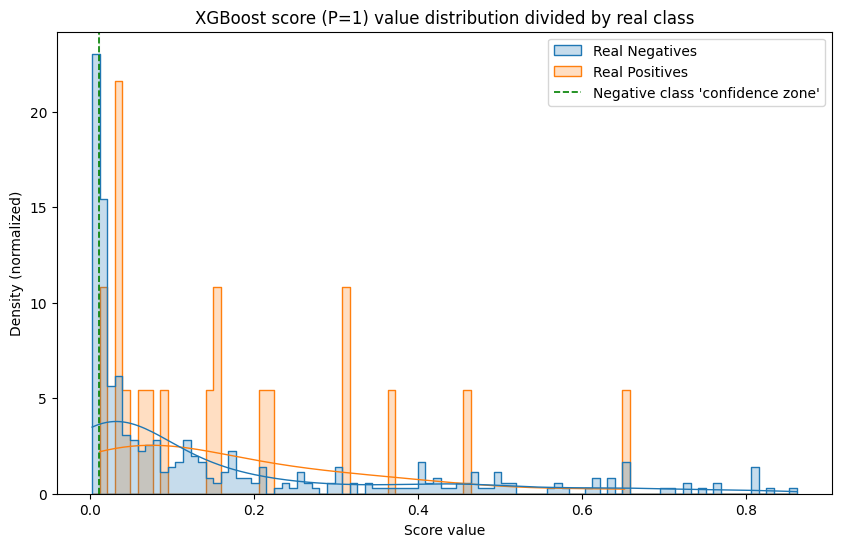

In [181]:
plt.figure(figsize=(10, 6))

ax = sns.histplot(
    data=df_check,
    x='score_xgb',
    hue='REINCIDENCIA_VIOLENTA',
    bins=93,
    stat='density',
    common_norm=False,
    element="step"
)

sns.kdeplot(
    data=df_check,
    x='score_xgb',
    hue='REINCIDENCIA_VIOLENTA',
    common_norm=False,
    linewidth=1,
    ax=ax,
    legend=False,
    cut=0,
    clip=(0, 1)
)

plt.title("XGBoost score (P=1) value distribution divided by real class")
plt.xlabel("Score value")
plt.ylabel("Density (normalized)")

plt.axvline(
    x=best_veto_threshold,
    color='green',
    linestyle='--',
    linewidth=1.2
)

plt.axvspan(thresholds.min(), best_veto_threshold, color='green', alpha=0.1)

legend = ax.legend_

new_line = Line2D([0], [0], color='green', linestyle='--', linewidth=1.2)

legend_handles = legend.legend_handles + [new_line]
legend_labels = ['Real Negatives', 'Real Positives', "Negative class 'confidence zone'"]

ax.legend(legend_handles, legend_labels)
plt.show()

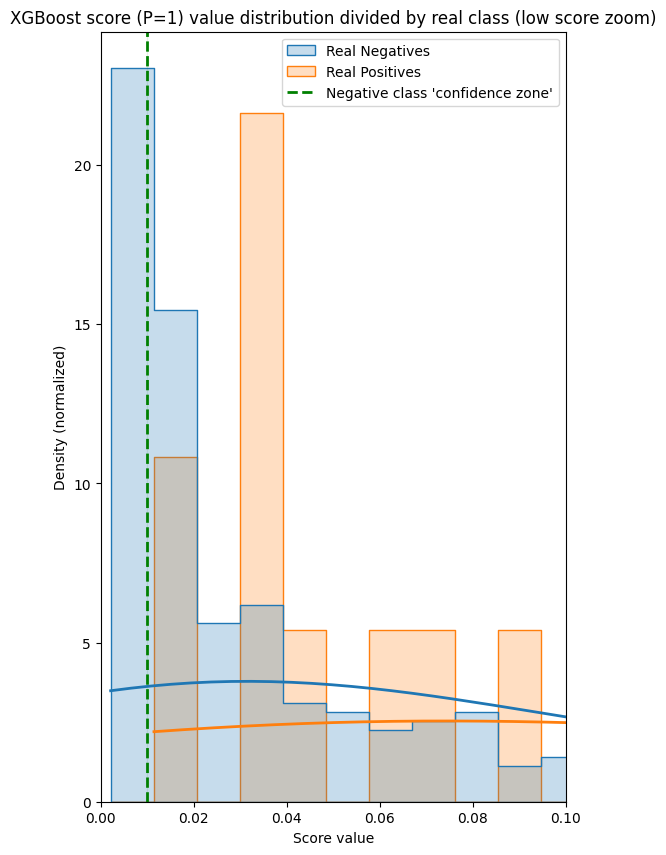

In [195]:
plt.figure(figsize=(6, 10))

ax = sns.histplot(
    data=df_check,
    x='score_xgb',
    hue='REINCIDENCIA_VIOLENTA',
    bins=93,
    stat='density',
    common_norm=False,
    element="step"
)

sns.kdeplot(
    data=df_check,
    x='score_xgb',
    hue='REINCIDENCIA_VIOLENTA',
    common_norm=False,
    linewidth=2,
    ax=ax,
    legend=False,
    cut=0,
    clip=(0, 1)
)

plt.title("XGBoost score (P=1) value distribution divided by real class (low score zoom)")
plt.xlabel("Score value")
plt.ylabel("Density (normalized)")

plt.axvline(
    x=best_veto_threshold,
    color='green',
    linestyle='--',
    linewidth=2
)

plt.axvspan(thresholds.min(), best_veto_threshold, color='green', alpha=0.1)

legend = ax.legend_

new_line = Line2D([0], [0], color='green', linestyle='--', linewidth=2)

legend_handles = legend.legend_handles + [new_line]
legend_labels = ['Real Negatives', 'Real Positives', "Negative class 'confidence zone'"]

ax.legend(legend_handles, legend_labels)
plt.xlim(0, 0.1)
plt.show()

**RisCanvi scoring comparison:**

In [114]:
print('Model score to RisCanvi score correlation:', df_check['score_xgb'].corr(df_check['V205_R1_REVI'], method='pearson').round(2))
print('Model score to real recidivism correlation:', df_check['score_xgb'].corr(df_check['REINCIDENCIA_VIOLENTA'], method='pearson').round(2))

Model score to RisCanvi score correlation: 0.27
Model score to real recidivism correlation: 0.02


In [115]:
print('Mean model score among RisCanvi high-score inmates:', df_check[df_check['class_rc']==1]['score_xgb'].mean().round(2))
print('Mean model score among RisCanvi low/medium-score inmates:', df_check[df_check['class_rc']==0]['score_xgb'].mean().round(2))

Mean model score among RisCanvi high-score inmates: 0.31
Mean model score among RisCanvi low/medium-score inmates: 0.14


-----

**Conclusions - FP mitigation via asymmetric ensembling (veto system)**

In this architecture, Logistic Regression (LR) serves as the primary decision engine. Its high interpretability is a strict legal and ethical requirement for predicting adverse outcomes (restricting individual rights / classifying as high-risk). 

However, during testing, the XGBoost model demonstrated a better negative class metrics (F1) below a specific probability threshold. We can leverage this property by introducing an **asymmetric algorithmic veto**:
* **Base decision:** LR defines the positive class based on its optimal threshold (positive class F1/precision).
* **FP filter (veto):** If an individual is classified as high-risk by LR, but their XGBoost score falls into the "negative class confidence zone", the final decision is overridden to the negative class (low-risk).

**Ethical & legal outcomes:** The "right to explanation" (e.g., GDPR Art. 22) mainly applies to adverse decisions. Using a complex, non-interpretable model (XGBoost) as a "black box" is problematic when restricting rights, but can be justifiable when *granting* them. By using XGBoost solely to eliminate FP generated by the LR model, we maximize individual fairness without sacrificing the interpretability required for high-risk classifications.

**Final classification (LR base + XGB mitigation):**

In [29]:
df_check['final_class'] = (
    (df_check['score_lr'] >= best_threshold_lr) & 
    (df_check['score_xgb'] >= best_veto_threshold)
).astype(int)

In [30]:
print('Final classification report:\n')
print(classification_report(df_check['REINCIDENCIA_VIOLENTA'], df_check['final_class']))

Final classification report:

              precision    recall  f1-score   support

           0       0.96      0.99      0.97       385
           1       0.38      0.15      0.21        20

    accuracy                           0.95       405
   macro avg       0.67      0.57      0.59       405
weighted avg       0.93      0.95      0.93       405



In [31]:
df_check[df_check['final_class']==1]['REINCIDENCIA_VIOLENTA'].value_counts()

REINCIDENCIA_VIOLENTA
0    5
1    3
Name: count, dtype: int64

**Conclusion: positive class precision for high-risk violent recidivism has been enhanced from `~7%` (RisCanvi) to `38%` (LR with XGB veto system).**

------

### **Final model vs RisCanvi - general comparison:**

**Checking connection to RisCanvi scores**:<br>
Assesing general resemblence of scoring logic of the final model to RisCanvi.

In [226]:
print('LR class to RisCanvi score correlation:', df_check['class_lr'].corr(df_check['class_rc'], method='pearson').round(2))
print('LR class to real recidivism correlation:', df_check['class_lr'].corr(df_check['REINCIDENCIA_VIOLENTA'], method='pearson').round(2))

LR class to RisCanvi score correlation: 0.23
LR class to real recidivism correlation: 0.2


In [227]:
print('LR + XGB class to RisCanvi score correlation:', df_check['final_class'].corr(df_check['class_rc'], method='pearson').round(2))
print('LR + XGB class to real recidivism correlation:', df_check['final_class'].corr(df_check['REINCIDENCIA_VIOLENTA'], method='pearson').round(2))

LR + XGB class to RisCanvi score correlation: 0.25
LR + XGB class to real recidivism correlation: 0.21


In [50]:
print('Predicted positive class rate among RisCanvi high-score inmates:', df_check[df_check['class_rc']==1]['final_class'].mean().round(2))
print('Predicted positive class rate among RisCanvi low/medium-score inmates:', df_check[df_check['class_rc']==0]['final_class'].mean().round(2))

Predicted positive class rate among RisCanvi high-score inmates: 0.13
Predicted positive class rate among RisCanvi low/medium-score inmates: 0.01


In [460]:
print('Mean RisCanvi score among high-risk model inmates:', df_check[df_check['class']==1]['V205_R1_REVI'].mean().round(2))
print('Mean RisCanvi score among low-risk model inmates:', df_check[df_check['class']==0]['V205_R1_REVI'].mean().round(2))

Mean RisCanvi score among high-risk model inmates: 1.87
Mean RisCanvi score among low-risk model inmates: 1.29


In [47]:
print(classification_report(df_check['class_rc'], df_check['final_class']))

              precision    recall  f1-score   support

           0       0.91      0.99      0.95       366
           1       0.62      0.13      0.21        39

    accuracy                           0.91       405
   macro avg       0.77      0.56      0.58       405
weighted avg       0.89      0.91      0.88       405



**Correlation of score to real target is increased** from `~0.11` (RisCanvi) to `~0.21` (LR + XGB)

**Low positive class recall** between RisCanvi and the final model may indicate differences in assesing high-score predictions. Next step would be confusion analysis (ex. FP uplift) in model outputs compared to RisCanvi.

-------

**Confusion matrices:**

In [48]:
from sklearn.metrics import confusion_matrix

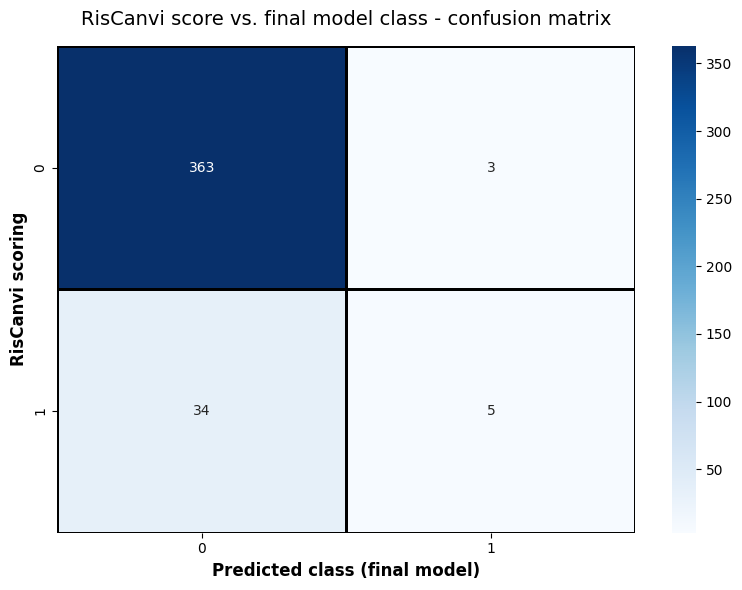

In [163]:
cm = confusion_matrix(df_check['class_rc'], df_check['final_class'])

plt.figure(figsize=(8, 6))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=2, linecolor='black')

ax.set_xlabel('Predicted class (final model)', fontsize=12, fontweight='bold')
ax.set_ylabel('RisCanvi scoring', fontsize=12, fontweight='bold')
ax.set_title('RisCanvi score vs. final model class - confusion matrix', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

In [348]:
cm = confusion_matrix(df_check['REINCIDENCIA_VIOLENTA'], df_check['final_class'])
cm

array([[380,   5],
       [ 17,   3]])

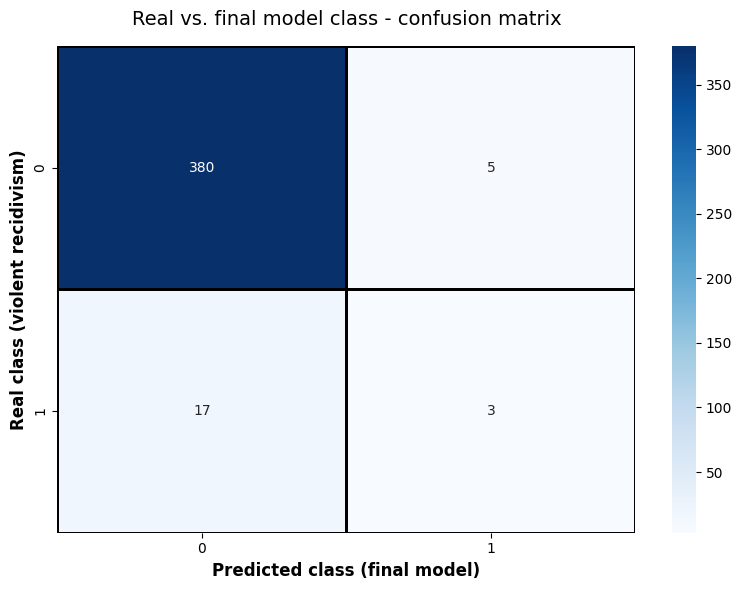

In [164]:
cm = confusion_matrix(df_check['REINCIDENCIA_VIOLENTA'], df_check['final_class'])

plt.figure(figsize=(8, 6))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=2, linecolor='black')

ax.set_xlabel('Predicted class (final model)', fontsize=12, fontweight='bold')
ax.set_ylabel('Real class (violent recidivism)', fontsize=12, fontweight='bold')
ax.set_title('Real vs. final model class - confusion matrix', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

-----

### **Final model vs RisCanvi - confusion analysis:**

**Score elevation (FP deterioration):<br>**
In rare cases the final model asseses higher score than RisCanvi, with 2/3 of elevated observations being False Positives (incorrect) and 1/3 being True Positive (correct), which means `~33%` accuracy in RisCanvi low score adjustment. Having said that, `40%` (2/5) of all model FP errors are correctly classified by RisCanvi and `60%` (3/5) are mistaken by both (precision resemblence).

In [107]:
elevated = df_check[(df_check['class_rc']==0) & (df_check['final_class']==1)]
elevated[['class_rc','final_class','REINCIDENCIA_VIOLENTA']]

,class_rc,final_class,REINCIDENCIA_VIOLENTA
1060,0,1,1
229,0,1,0
630,0,1,0


**"Saved" inmates (False Positive uplift):**<br>
Great majority of records that final model "saves" from RisCanvi high score assesment are False Positives. The ratio of real positive class in a cohort with lowered model score compared to RisCanvi score ("saved") is much lower than test set positive class base rate, meaning there's significant overrepresentation of real negative observations in saved cohort).

$$\text{FP Uplift} = \frac{P(\text{Real Negative} \mid \text{Saved})}{P(\text{Real Negative})}$$

In [118]:
saved = df_check[(df_check['class_rc']==1) & (df_check['final_class']==0)]
saved[['class_rc','final_class','REINCIDENCIA_VIOLENTA']]

,class_rc,final_class,REINCIDENCIA_VIOLENTA
344,1,0,0
1967,1,0,0
426,1,0,0
1162,1,0,0
359,1,0,0
1150,1,0,0
143,1,0,0
51,1,0,0
370,1,0,0
1830,1,0,0


In [119]:
print("Positive class base rate (test set):")
df_check['REINCIDENCIA_VIOLENTA'].value_counts(normalize=True) * 100

Positive class base rate (test set):


REINCIDENCIA_VIOLENTA
0    95.061728
1     4.938272
Name: proportion, dtype: float64

In [172]:
print("Positive class rate in 'saved' cohort:")
saved['REINCIDENCIA_VIOLENTA'].value_counts(normalize=True) * 100

Positive class rate in 'saved' cohort:


REINCIDENCIA_VIOLENTA
0    97.058824
1     2.941176
Name: proportion, dtype: float64

In [148]:
p_real_negative = (df_check['REINCIDENCIA_VIOLENTA'] == 0).mean() # negative class probability in test set
p_real_negative_saved = (saved['REINCIDENCIA_VIOLENTA'] == 0).mean() # negative class probability in saved cohort

lift = p_real_negative_saved / p_real_negative # uplift

print(f"False Positive uplift: {lift:.4f} ({(lift-1)*100:.1f}%)")

False Positive uplift: 1.0210 (2.1%)


**Mutual positives :<br>**
Cases where both RisCanvi and the final model predict positive.<br>
`~63%` (5/8) of all model Predicted Positives were also high-score (Positive) in RisCanvi, with `60%` (3/5) of all mutual Predicted Positives being errors (Real Negative), as mentioned above. 

In [149]:
mutual_pos = df_check[(df_check['class_rc']==1) & (df_check['final_class']==1)]
mutual_pos[['class_rc','final_class','REINCIDENCIA_VIOLENTA']]

,class_rc,final_class,REINCIDENCIA_VIOLENTA
1196,1,1,1
1248,1,1,1
1919,1,1,0
342,1,1,0
1867,1,1,0


**Mutual negatives:<br>**
Cases where both RisCanvi and the final model predict negative.<br>
`~91%` (363/397) of all model Predicted Negatives were also low or medium score (Negative) in RisCanvi, with `~4.4%` (16/363) of all mutual Predicted Negatives being errors (Real Positive).

In [157]:
mutual_neg = df_check[(df_check['class_rc']==0) & (df_check['final_class']==0)]
mutual_neg[['class_rc','final_class','REINCIDENCIA_VIOLENTA']]

,class_rc,final_class,REINCIDENCIA_VIOLENTA
157,0,0,0
490,0,0,0
1689,0,0,0
1633,0,0,0
1147,0,0,0
...,...,...,...
1758,0,0,0
1300,0,0,0
882,0,0,0
1962,0,0,1


In [151]:
mutual_neg[['class_rc','final_class','REINCIDENCIA_VIOLENTA']].value_counts()

class_rc  final_class  REINCIDENCIA_VIOLENTA
0         0            0                        347
                       1                         16
Name: count, dtype: int64

-------

### **Final model vs. RisCanvi - fariness comparison:**

In [174]:
df_check.groupby('final_class')['REINCIDENCIA_VIOLENTA'].mean() 

final_class
0    0.042821
1    0.375000
Name: REINCIDENCIA_VIOLENTA, dtype: float64

In [169]:
df_check.groupby('class_rc')['REINCIDENCIA_VIOLENTA'].mean()

class_rc
0    0.046448
1    0.076923
Name: REINCIDENCIA_VIOLENTA, dtype: float64

**Full context dataset with test rows only (+ scores):**

In [238]:
df_all_check = df_all.loc[x_test.index].copy()
df_all_check = df_all_check.drop(['REINCIDENCIA_VIOLENTA','V205_R1_REVI'], axis=1) # de-duplicating
target_cols = df_check[df_check.columns[-8:]]
df_all_check = pd.concat([df_all_check, target_cols], axis=1)

In [283]:
riscanvi_features = ['V72_DELICTEPBVIOL','V139_EDAT_DELICTEPBASE','V76_R3C_F03_IntoxicacioDelicteBase','V77_R3C_F04_VictimesLesions','V86_DURADA_PENA_RisCanvi',
                     'V78_R3C_F07_HistoriaViolencia','V79_R3C_F08_IniciActivitatDelictiva','V80_R3C_F09_IncrementGravetatDelictes','V104_R3C_F10_ConflictesAmbInterns',
                     'V105_R3C_F11_IncomplimentsMesures','V106_R3C_F12_ExpedientsDisciplinaris','V107_R3C_F13_EvasionsFugues','V108_R3C_F14_RegressioGrau','V109_R3C_F15_TrencamentPermisos',
                     'V29_R3C_F16_DesajustInfantil','V30_R3C_F18_NivellEducatiu','V31_R3C_F19_ProblemesOcupacio','V32_R3C_F20_MancaRecursosEconomics','V33_R3C_F21_AbsenciaPlansFutur','V34_R3C_F22_AntecedentsFamilia',
                     'V35_R3C_F23_SocialitzacioProblematica','V36_R3C_F24_MancaSuportFamiliarSocial','V37_R3C_F25_PertinençaBandes','V38_R3C_F26_PertinençaGrupRisc','V39_R3C_F27_RolDelictiuDestacat',
                     'V40_R3C_F28_VictimaVIGE','V41_R3C_F29_CarreguesFamiliars','V42_R3C_F30_ConsumDrogues','V43_R3C_F31_ConsumAlcohol','V44_R3C_F32_TranstornMentalSever','V45_R3C_F33_ComportamentSexualRisc',
                     'V46_R3C_F34_RespostaLimitadaTractament','V47_R3C_F35_TranstornPersonalitat','V48_R3C_F36_PobreAfrontamentEstres','V49_R3C_F37_IntentsAutolesio','V50_R3C_F38_ActitudsProcriminals','V51_R3C_F39_BaixCI',
                     'V52_R3C_F40_Temeritat','V53_R3C_F41_Impulsivitat','V54R3C_F42_Hostilitat','V55_R3C_F43_Irresponsabilitat']

------

**Performance parity**:<br>
Checking the LR+XGB differentiating ability across various subgroups. Comparing the subgroup's **capture rate** (`predicted positive / actual positive (target)`) against the **global baseline** (`40%`).<br>A **higher capture rate** within subgroup indicates that the model overclassifies inmates within that subgroup as high-risk.<br>A **lower capture rate** means the model underclassifies inmates within that subgroup as high-risk, meaning that belonging to given subgroup has 'protective' effect on the assessment.<br>**Close to global capture rate** (difference ~0%) means the model's performance on the subgroup matches its global baseline, indicating no significant predictive bias for that group.

**Global capture rate: `40%` (8/20)**

In [301]:
from utils import check_predictive_parity # own function checking predictive parity of subgroups

In [331]:
segments_to_test = ['V18_SEXE','V19_ESTRANGERS','V30_R3C_F18_NivellEducatiu', 'V27_EDAT_PB_AGRUPADA'] # bias-prone features
report = check_predictive_parity(df_all_check, 'final_class', 'REINCIDENCIA_VIOLENTA', subgroups=segments_to_test)

print('Grouped predictive disparity (descending) - worst parity (highest capture rate difference from baseline) first:')
display(report)

Grouped predictive disparity (descending) - worst parity (highest capture rate difference from baseline) first:


,subgroup,col,val,size,target_count,target_rate,pred_rate,capture_rate,capture_diff_pct
0,V30_R3C_F18_NivellEducatiu == 1,V30_R3C_F18_NivellEducatiu,1.0,178,12,0.06742,0.04494,0.66667,66.67
1,V27_EDAT_PB_AGRUPADA == 1.0,V27_EDAT_PB_AGRUPADA,1.0,112,11,0.09821,0.05357,0.54545,36.36
2,V27_EDAT_PB_AGRUPADA == 2.0,V27_EDAT_PB_AGRUPADA,2.0,206,7,0.03398,0.00971,0.28571,28.57
3,V19_ESTRANGERS == 2,V19_ESTRANGERS,2.0,163,6,0.03681,0.01840,0.50000,25.00
4,V19_ESTRANGERS == 1,V19_ESTRANGERS,1.0,242,14,0.05785,0.02066,0.35714,10.71
5,V18_SEXE == 1,V18_SEXE,1.0,380,20,0.05263,0.02105,0.40000,0.00


**Conclusions:**
The analysis reveals significant variance in how the model distributes its high-risk predictions relative to the actual recidivism rates of different subgroups.

*   **Disproportionate strictness (positive class over-representation):**
    The model assigns high-risk scores at a substantially higher rate than its global baseline (40%) to the following groups:
    *   **Lowest Education (`V30_R3C_F18_NivellEducatiu == 1`):** Capture Rate of **66.7%** (+66.67% deviation from baseline).
    *   **Youngest Inmates (`V27_EDAT_PB_AGRUPADA == 1.0`):** Capture Rate of **54.5%** (+36.36% deviation from baseline).
    *   **Foreigners (`V19_ESTRANGERS == 2`):** Capture Rate of **50.0%** (+25.00% deviation from baseline).
    
    *Conclusion:* Belonging to these subgroups significantly increases the likelihood of receiving a high-risk score relative to the actual underlying risk of the group.

*   **Disproportionate leniency (positive class under-representation):**
    The model is significantly less likely to assign high-risk scores to certain groups compared to its global baseline:
    *   **Older Inmates (`V27_EDAT_PB_AGRUPADA == 2.0`):** Capture Rate of **28.6%** (-28.57% deviation from baseline).
    
    *Conclusion:* The model exhibits a protective bias (leniency) toward older inmates, classifying them as high-risk less often than their actual recidivism rate would globally dictate.

-------

**Distribution bias**:<br>
Checking False Positives overrepresentation in different subgroups.

**Age:**

In [284]:
print('Mean values of continouous variables grouped into assesed score and real class:\n')
df_all_check[['V139_EDAT_DELICTEPBASE','REINCIDENCIA_VIOLENTA','final_class']].groupby(['REINCIDENCIA_VIOLENTA','final_class']).mean()

Mean values of continouous variables grouped into assesed score and real class:



V139_EDAT_DELICTEPBASE
REINCIDENCIA_VIOLENTA final_class                        
0                     0                         37.650000
                      1                         30.600000
1                     0                         33.352941
                      1                         22.000000

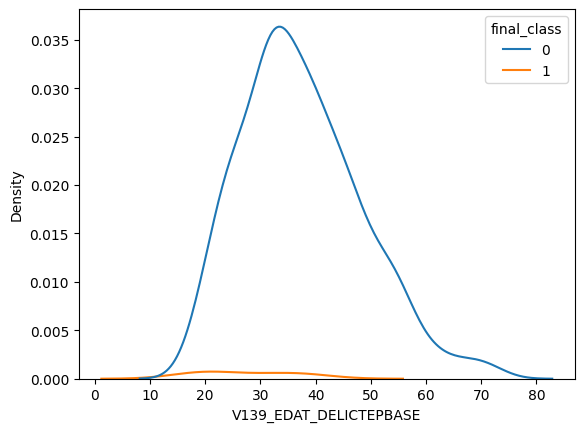

In [342]:
sns.kdeplot(data=df_all_check, x='V139_EDAT_DELICTEPBASE', hue='final_class')
plt.show()

In [345]:
df_check[df_check['final_class']==1]['V139_EDAT_DELICTEPBASE'].describe()

count     8.00000
mean     27.37500
std       8.50105
min      18.00000
25%      19.75000
50%      26.00000
75%      34.75000
max      39.00000
Name: V139_EDAT_DELICTEPBASE, dtype: float64

In [346]:
df_check[df_check['final_class']==0]['V139_EDAT_DELICTEPBASE'].describe()

count    397.000000
mean      37.465995
std       10.892124
min       18.000000
25%       30.000000
50%       36.000000
75%       44.000000
max       73.000000
Name: V139_EDAT_DELICTEPBASE, dtype: float64

**Categorical variables:**

In [288]:
df_long = df_all_check.melt(
    id_vars=['REINCIDENCIA_VIOLENTA','final_class'],
    value_vars=riscanvi_features,
    var_name='feature',
    value_name='value'
)

bias_table = (
    df_long
    .groupby(['feature','value','REINCIDENCIA_VIOLENTA','final_class'])
    .size()
    .reset_index(name='count')
)

bias_table['pct'] = (
    bias_table.groupby(['feature','value','REINCIDENCIA_VIOLENTA'])['count']
    .transform(lambda x: x/x.sum())
)

baseline = (
    df_all_check.groupby(['REINCIDENCIA_VIOLENTA','final_class'])
    .size()
    .groupby(level=0)
    .transform(lambda x: x/x.sum())
    .rename('baseline')
    .reset_index()
)

bias_table = bias_table.merge(
    baseline,
    on=['REINCIDENCIA_VIOLENTA','final_class']
)

bias_table['bias_ratio'] = bias_table['pct'] / bias_table['baseline']

In [289]:
biased_fp = bias_table[
    (bias_table.REINCIDENCIA_VIOLENTA == 0) &
    (bias_table.final_class == 1) &
    (bias_table.bias_ratio > 1) & # any overrepresentation of FP
    (bias_table['count'] >= 3) # over 3 count
].sort_values('bias_ratio', ascending=False)

In [290]:
biased_fp[['feature','value','count','bias_ratio']]

,feature,value,count,bias_ratio
467,V79_R3C_F08_IniciActivitatDelictiva,1.0,4,18.117647
241,V38_R3C_F26_PertinençaGrupRisc,1.0,3,7.218750
450,V77_R3C_F04_VictimesLesions,1.0,5,5.422535
138,V29_R3C_F16_DesajustInfantil,1.0,4,5.403509
458,V78_R3C_F07_HistoriaViolencia,1.0,5,4.529412
209,V35_R3C_F23_SocialitzacioProblematica,2.0,3,4.442308
478,V80_R3C_F09_IncrementGravetatDelictes,1.0,4,3.242105
30,V106_R3C_F12_ExpedientsDisciplinaris,2.0,3,3.208333
433,V72_DELICTEPBVIOL,1.0,5,2.894737
265,V41_R3C_F29_CarreguesFamiliars,1.0,3,2.686047


**False Positives Overrepresentation: RisCanvi vs. Final Model (LR+XGB)**<br><br>

| Feature Category | RisCanvi | Final Model (LR + XGB) |
| :--- | :--- | :--- |
| **Primary Drivers** | Subjective / clinical assessment (e.g., *V50 Actituds Procriminals*, *V47 Transtorn Personalitat*) | Objective / historical data (e.g., *V79 Inici Activitat Delictiva*, *V78 Historia Violencia*) |
| **Bias Ratio Baseline** | ~7.5% | ~1.3% |
| **Bias Ratio Peaks** | Lower (up to ~4.7x overrepresentation) | Higher (up to ~18.1x overrepresentation) |
| **FP Count (Volume)** | Higher (counts of 20-70 per subgroup) | Lower (counts of 3-5 per subgroup) |

**Key analytical issues:**

* **Lower FP baseline ratio:**
The baseline ratio of FP has decreased from `~7.5%` to `~1.3%`, meaning generally fewer inmates are mistakenly classified as high-risk.

* **Sample size issue:**
The final model yields only 5 False Positives on the test set. Consequently, the extreme bias ratio (18.1x for early criminal onset) is driven by just 4 individual cases. This implies a more statistically unstable error distribution compared to RisCanvi's broader FP volume.

* **Hard data as protected attribute proxies:**
While the final model avoids human-in-the-loop subjectivity (human-based assesment) by relying on static variables (age of onset, criminal record), these variables often serve as strong proxies for protected attributes (e.g., socio-economic background, ethnicity), as has been shown in pipeline_1. This shifts the model from individual subjective bias to systemic historical bias, but increases standarization potential, through limiting the importance of human-assesment on misclassifications. 

* **The static risk (impossible rehabilitation):**
RisCanvi incorporates dynamic clinical factors, theoretically allowing an inmate's risk score to decrease upon behavioral improvement. The final model relies predominantly on static variables (past events). Consequently, it creates a feedback loop where an inmate's high-risk classification becomes permanent, negating the measurable impact of rehabilitation.

------

### Performance Comparison: RisCanvi vs. Veto model (LR+XGB)

| Metric | Historical RisCanvi (Audit) | LR+XGB (veto model) |
| :--- | :--- | :--- |
| **Precision (PPV)** | ~17.9% / ~8% | 38.0% |
| **Recall (TPR)** | ~77.0% | 15.0% |
| **Specificity (TNR)** | ~57.0% | 99.0% |

### Results Interpretation:
1. **Precision vs. Recall**: The original RisCanvi may have been optimized for sensitivity (Recall: 77%), which resulted in very low precision (PPV: 17.9% for medium or high risk violent recidivism or 8% for high risk violent recidivism-only). The LR+XGB model was optimized for precision, resulting in 38% high risk violent recidivism precision.
2. **Selectivity**: The LR+XGB model (even without pre-processing de-biasing) is significantly more selective. While it *"catches"* fewer recidivists (only 15% of real recidivists are correctly classified as high-risk) and issues high-risk scores far less frequently (a capture rate of 40%, meaning it issues 4 high-risk scores for every 10 actual recidivists), its predictions for high risk violent recidivism are almost 5 times more reliable (PPV: 38.0% vs. 8%).
3. **Fairness (Specificity)**: The higher specificity of LR+XGB (99% vs 57.0%) means the model is much less likely to misclassify low-risk individuals as potential violent recidivists, which is crucial from an ethical and legal standpoint.